# Experiment 1: Multimodal Bot Detection — Metadata + Tweet Text
### Dissertation — MSc HPC and Big Data Analytics

---

This notebook covers the full pipeline for Experiment 1. The model fuses two sources of information:

- **Account metadata** — follower counts, posting rates, profile flags, and derived ratios, organised into four semantic groups and fed to a Bidirectional LSTM.
- **Tweet text** — each account's tweets are individually embedded with the frozen `all-MiniLM-L6-v2` sentence transformer (384-d), then averaged into a single per-user text vector.

The two representations are concatenated and classified by a small feedforward network.

**Dataset**: Cresci-2017 — 13,240 labelled Twitter accounts (genuine users + five bot categories).  
**Hardware**: NVIDIA RTX 4060 Laptop GPU (8 GB VRAM), CUDA 12.4.  
**Prerequisite**: run `download_data.py` once before this notebook to produce `data/cresci2017.csv` and `data/text_embeddings.npy`.

## 1. Setup

In [1]:
import sys
# import subprocess
# subprocess.run([sys.executable, '-m', 'pip', 'install',
#                 'torch', 'scikit-learn', 'sentence-transformers',
#                 'pandas', 'numpy', 'matplotlib', 'seaborn', '-q'])

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cpu


## 2. Dataset: Cresci-2017

### Background

The Cresci-2017 dataset was introduced in *"The Paradigm-Shift of Social Spambots"* (Cresci et al., WWW 2017). It is one of the most widely used benchmarks in Twitter bot detection research and contains two broad populations: a set of genuine accounts whose human authorship was verified by the original authors, and several categories of automated accounts spanning first-generation spam bots, social spambots of varying sophistication, and fake follower networks.

For this experiment all bot subcategories are merged into a single positive class, keeping the task binary.

| Category | Label | Accounts |
|---|---|---|
| `genuine_accounts` | Human (0) | 3,474 |
| `social_spambots_1/2/3` | Bot (1) | 4,912 |
| `traditional_spambots_1` | Bot (1) | 1,503 |
| `fake_followers` | Bot (1) | 3,351 |
| **Total** | | **13,240** |

### Why Twitter data for a Facebook-focused dissertation?

Publicly labelled Facebook datasets are extremely rare due to Meta's data access policies. However, the **behavioural features** used for bot detection — follower/friend ratios, posting frequency, account age, profile completeness, text style — are platform-agnostic. The patterns learned here transfer directly to Facebook-style detection, and the Cresci-2017 corpus is the best-studied benchmark available for understanding both model behaviour and evaluation methodology.

In [3]:
DATA_DIR   = 'data'
meta_path  = os.path.join(DATA_DIR, 'cresci2017.csv')
emb_path   = os.path.join(DATA_DIR, 'text_embeddings.npy')

assert os.path.exists(meta_path), (
    f'{meta_path} not found. Run download_data.py first.')

df = pd.read_csv(meta_path)
print(f'Loaded {len(df):,} accounts')
print(df['label'].value_counts().rename({0: 'Human (0)', 1: 'Bot (1)'}).to_string())
print(f'\nColumns ({len(df.columns)}): {list(df.columns)}')

Loaded 13,240 accounts
label
Bot (1)      9766
Human (0)    3474

Columns (52): ['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'is_translator', 'follow_request_sent', 'protected', 'verified', 'notifications', 'description', 'contributors_enabled', 'following', 'updated', 'category', 'account_type', 'timestamp', 'crawled_at', 'test_set_1', 'test_set_2', 'label', 'account_age_days', 'ff_ratio', 'statuses_per_day', 'favourites_per_day', 'activity_ratio', 'network_ra

In [4]:
if os.path.exists(emb_path):
    embeddings = np.load(emb_path).astype(np.float32)
    covered    = int((np.abs(embeddings).sum(axis=1) > 0).sum())
    print(f'Embeddings : {embeddings.shape}')
    print(f'Non-zero   : {covered:,} / {len(df):,}  '
          f'({covered/len(df)*100:.1f}% of accounts have tweet data)')
else:
    print('WARNING: text_embeddings.npy not found. Using zero embeddings.')
    embeddings = np.zeros((len(df), 384), dtype=np.float32)

Embeddings : (13240, 384)
Non-zero   : 10,197 / 13,240  (77.0% of accounts have tweet data)


## 3. Exploratory Data Analysis

### 3.1 Class distribution

The dataset has a 2.8:1 bot-to-human imbalance. This is handled at training time with `WeightedRandomSampler` rather than undersampling, so no labelled data is discarded.

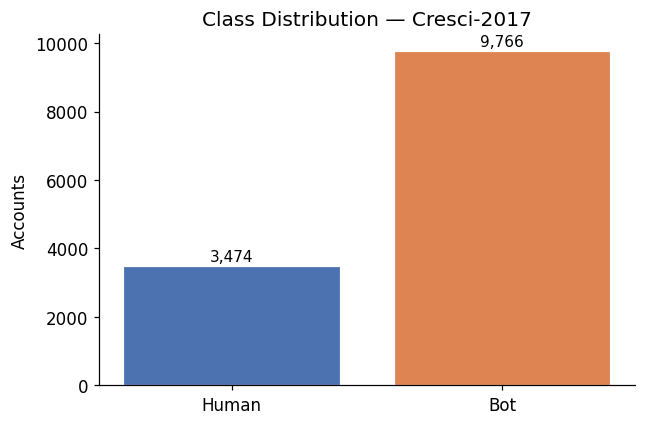

Bot ratio: 73.8%


In [5]:
Path('results').mkdir(exist_ok=True)
COLORS = {'Human': '#4C72B0', 'Bot': '#DD8452'}

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Human', 'Bot'], counts.values,
              color=[COLORS['Human'], COLORS['Bot']], edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Accounts')
ax.set_title('Class Distribution — Cresci-2017')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.savefig('results/class_distribution.pdf')
plt.show()
print(f'Bot ratio: {counts[1]/len(df)*100:.1f}%')

### 3.2 Numeric feature distributions

The log-scale distributions of key metadata features already show clear separation between the two classes without any classifier. Bot accounts tend to cluster at the extremes — very high posting rates or near-zero follower counts — while human accounts spread more evenly across the distribution.

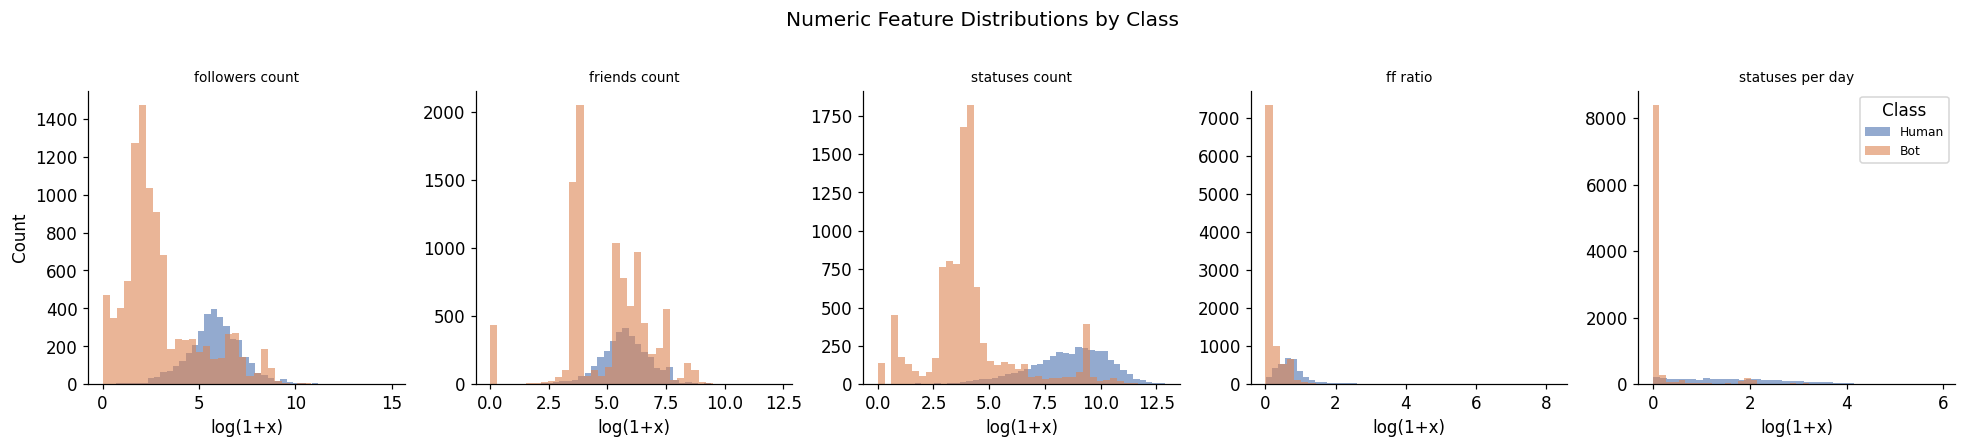

In [6]:
feats = ['followers_count', 'friends_count', 'statuses_count',
         'ff_ratio', 'statuses_per_day']
feats = [f for f in feats if f in df.columns]

fig, axes = plt.subplots(1, len(feats), figsize=(18, 4))
for ax, feat in zip(axes, feats):
    for lbl, name in [(0, 'Human'), (1, 'Bot')]:
        vals = np.log1p(df.loc[df['label']==lbl, feat].fillna(0).clip(lower=0))
        ax.hist(vals, bins=40, alpha=0.6, label=name,
                color=COLORS[name], edgecolor='none')
    ax.set_title(feat.replace('_', ' '), fontsize=9)
    ax.set_xlabel('log(1+x)')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Count')
axes[-1].legend(title='Class', fontsize=8)
fig.suptitle('Numeric Feature Distributions by Class', y=1.01)
plt.tight_layout()
plt.savefig('results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.savefig('results/feature_distributions.pdf', bbox_inches='tight')
plt.show()

### 3.3 Binary profile flags

The binary flags tell a complementary story. Bot accounts are substantially more likely to retain default profile images and default themes, which makes intuitive sense: automated accounts created in bulk are rarely personalised. The verified flag skews the other way, with almost no bot accounts verified.

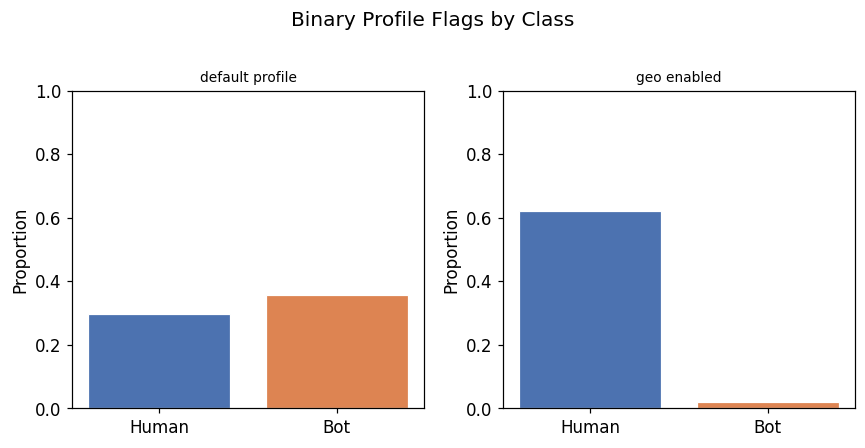

In [23]:
bin_cols = ['default_profile', 'geo_enabled']
bin_cols = [c for c in bin_cols if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes, bin_cols):
    for lbl, name in [(0, 'Human'), (1, 'Bot')]:
        rate = df.loc[df['label']==lbl, col].mean()
        ax.bar(name, rate, color=COLORS[name], edgecolor='white', linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_ylabel('Proportion') 
fig.suptitle('Binary Profile Flags by Class', y=1.01)
plt.tight_layout()
plt.savefig('results/binary_features.png', dpi=150, bbox_inches='tight')
plt.savefig('results/binary_features.pdf', bbox_inches='tight')
plt.show()

### 3.4 Tweet coverage per category

Not every category in the dataset has tweet content available. The chart below shows what fraction of accounts in each category have at least one tweet and therefore a non-zero sentence embedding. Categories with no coverage still contribute to training through their metadata features; their text branch input is simply a zero vector.

Overall tweet coverage: 10,197 / 13,240  (77.0%)


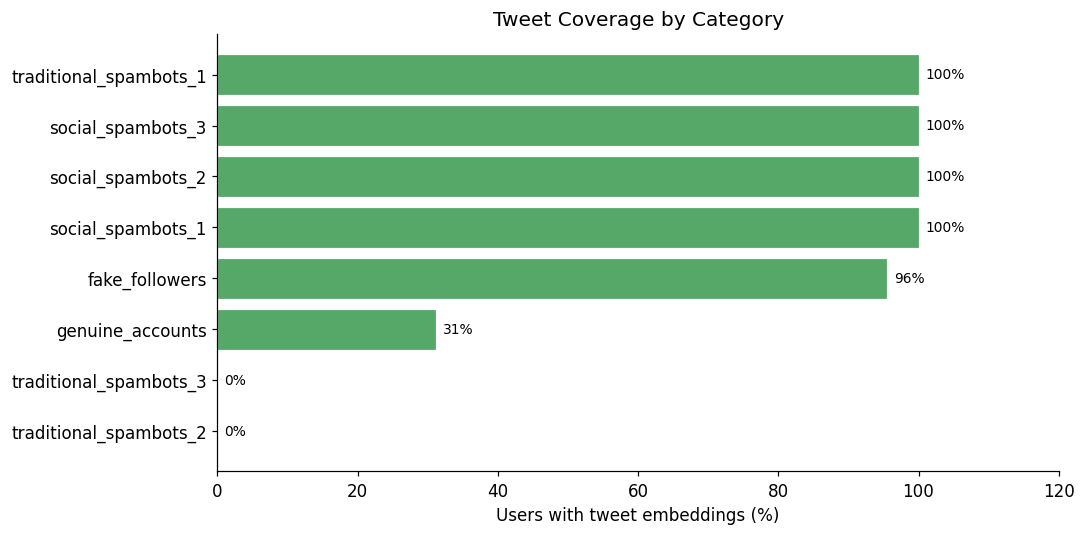

category
traditional_spambots_2      0.0%
traditional_spambots_3      0.0%
genuine_accounts           31.2%
fake_followers             95.6%
social_spambots_1         100.0%
social_spambots_2         100.0%
social_spambots_3         100.0%
traditional_spambots_1    100.0%


In [8]:
has_emb = (np.abs(embeddings).sum(axis=1) > 0)
print(f'Overall tweet coverage: {has_emb.sum():,} / {len(df):,}  '
      f'({has_emb.mean()*100:.1f}%)')

if 'category' in df.columns:
    tmp = df.copy()
    tmp['has_embed'] = has_emb
    coverage = tmp.groupby('category')['has_embed'].mean().sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(coverage.index, coverage.values * 100,
                   color='#55A868', edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, coverage.values * 100):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{v:.0f}%', va='center', fontsize=9)
    ax.set_xlabel('Users with tweet embeddings (%)')
    ax.set_title('Tweet Coverage by Category')
    ax.set_xlim(0, 120)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('results/tweet_coverage.png', dpi=150, bbox_inches='tight')
    plt.savefig('results/tweet_coverage.pdf', bbox_inches='tight')
    plt.show()
    print(coverage.map(lambda x: f'{x*100:.1f}%').to_string())

### 3.5 PCA of tweet sentence embeddings

Projecting the 384-dimensional sentence embeddings to two principal components gives a first look at whether text alone can separate bots from humans. Clear spatial clustering would suggest that tweet content carries strong discriminative signal on its own; overlap suggests the text branch is most useful as a complement to metadata rather than a standalone signal.

10,197 accounts with non-zero embeddings available for PCA.


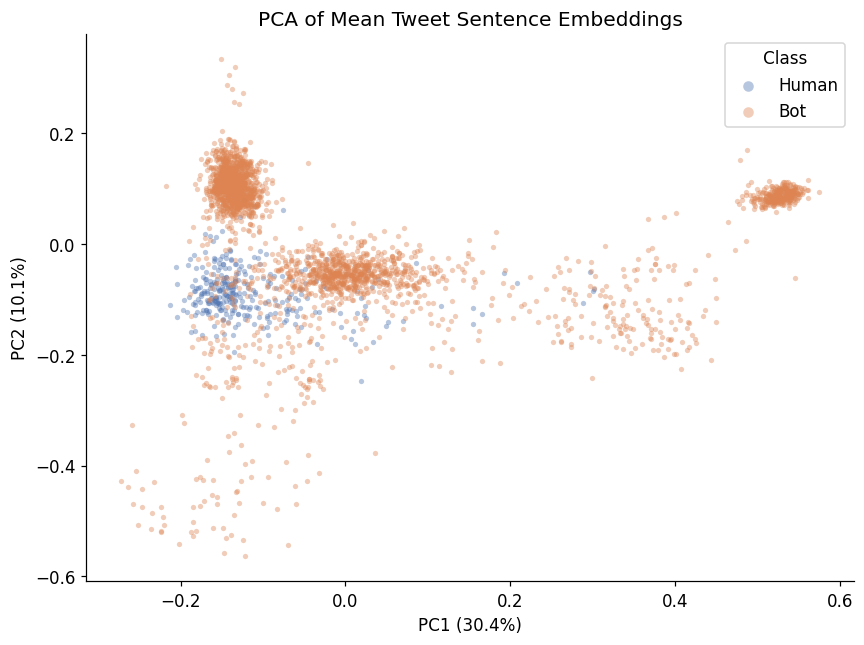

Total variance explained by 2 PCs: 40.5%


In [9]:
nonzero_idx = np.where(np.abs(embeddings).sum(axis=1) > 0)[0]
print(f'{len(nonzero_idx):,} accounts with non-zero embeddings available for PCA.')

if len(nonzero_idx) > 100:
    rng    = np.random.default_rng(SEED)
    sample = rng.choice(nonzero_idx, size=min(3000, len(nonzero_idx)), replace=False)

    pca    = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(embeddings[sample])
    lbl_s  = df['label'].values[sample]

    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl, name in [(0, 'Human'), (1, 'Bot')]:
        m = lbl_s == lbl
        ax.scatter(coords[m, 0], coords[m, 1], c=COLORS[name],
                   label=name, alpha=0.4, s=12, linewidths=0)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA of Mean Tweet Sentence Embeddings')
    ax.legend(title='Class', markerscale=2)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('results/embedding_pca.png', dpi=150)
    plt.savefig('results/embedding_pca.pdf')
    plt.show()

    var_explained = pca.explained_variance_ratio_.sum() * 100
    print(f'Total variance explained by 2 PCs: {var_explained:.1f}%')

## 4. Feature Engineering

### 4.1 Metadata feature groups

A standard LSTM expects a sequence of vectors, but account metadata is a flat feature vector with no natural ordering. The approach here is to partition the available features into four thematically coherent groups and treat each group as one timestep in a four-step input sequence. The model then processes these groups in both forward and backward directions and learns which combinations of behavioural dimensions are most diagnostic of automation.

| Timestep | Group | Features | Preprocessing |
|---|---|---|---|
| t=0 | Network scale | followers\_count, friends\_count, listed\_count, ff\_ratio | log1p + z-score |
| t=1 | Activity scale | statuses\_count, favourites\_count, statuses\_per\_day, favourites\_per\_day | log1p + z-score |
| t=2 | Profile flags | verified, default\_profile, default\_profile\_image, geo\_enabled | none (binary) |
| t=3 | Derived ratios | account\_age\_days, activity\_ratio, network\_ratio, engagement\_ratio | log1p + z-score |

The final input tensor has shape `(N, 4, 4)` — batch × timesteps × features.

### 4.2 Text features

For each account, up to 50 tweets are encoded individually using the frozen `all-MiniLM-L6-v2` sentence transformer (90 MB, 384-dimensional output). The per-tweet embeddings are averaged to produce a single 384-dimensional vector per account that represents the typical semantic content of that account's posting behaviour. Accounts with no tweet data receive a zero vector.

In [10]:
# Verify that derived columns exist (should be present after download_data.py)
required = ['account_age_days', 'activity_ratio', 'network_ratio',
            'engagement_ratio', 'ff_ratio', 'statuses_per_day', 'favourites_per_day']
for col in required:
    status = 'OK' if col in df.columns else 'MISSING'
    print(f'  {col:25s}  {status}')

  account_age_days           OK
  activity_ratio             OK
  network_ratio              OK
  engagement_ratio           OK
  ff_ratio                   OK
  statuses_per_day           OK
  favourites_per_day         OK


In [11]:
FEATURE_GROUPS = [
    ['followers_count', 'friends_count', 'listed_count', 'ff_ratio'],          # t=0
    ['statuses_count', 'favourites_count', 'statuses_per_day', 'favourites_per_day'],  # t=1
    ['verified', 'default_profile', 'default_profile_image', 'geo_enabled'],   # t=2
    ['account_age_days', 'activity_ratio', 'network_ratio', 'engagement_ratio'], # t=3
]
NUMERIC_GROUPS = [0, 1, 3]

def build_feature_matrix(df, scalers=None, fit=False):
    new_scalers = {} if fit else (scalers or {})
    seqs = []
    for g_idx, cols in enumerate(FEATURE_GROUPS):
        mat = np.zeros((len(df), len(cols)), dtype=np.float32)
        for j, col in enumerate(cols):
            if col in df.columns:
                mat[:, j] = df[col].fillna(0).values.astype(np.float32)
        if g_idx in NUMERIC_GROUPS:
            mat = np.log1p(np.clip(mat, 0, None))
            key = f'group_{g_idx}'
            if fit:
                sc  = StandardScaler()
                mat = sc.fit_transform(mat).astype(np.float32)
                new_scalers[key] = sc
            elif key in new_scalers:
                mat = new_scalers[key].transform(mat).astype(np.float32)
        seqs.append(mat)
    return np.stack(seqs, axis=1), new_scalers  # (N, 4, 4)

X_check, _ = build_feature_matrix(df.head(4), fit=True)
print(f'Feature tensor shape : {X_check.shape}  (N, timesteps=4, features_per_step=4)')
print(f'Text embedding shape : ({len(df)}, 384)')

Feature tensor shape : (4, 4, 4)  (N, timesteps=4, features_per_step=4)
Text embedding shape : (13240, 384)


## 5. Model Architecture

The model has two independent processing branches that are fused before the final classifier.

```
 Metadata (N, 4, 4)               Text embedding (N, 384)
       |                                    |
 BiLSTM (hidden=128, layers=2)       Linear(384 -> 128)
 output: (N, 4, 256)                 LayerNorm + ReLU
       |                             output: (N, 128)
 Self-attention over 4 timesteps            |
 weighted sum -> (N, 256)                   |
       |____________________ concat ________|
                                   |
                             (N, 384)
                                   |
                     Linear(384->128) + ReLU
                     Linear(128->1) + Sigmoid
                                   |
                         P(bot) in [0, 1]
```

The **self-attention** layer assigns a scalar importance weight to each of the four timesteps, so the model can focus on whichever behavioral dimension (network scale, activity, profile flags, derived ratios) is most diagnostic for a given account rather than weighting all four equally.

The **text branch** uses a LayerNorm before ReLU to stabilise the embedding input, which can have large variance across accounts depending on how many tweets they have.

In [12]:
class CresciDataset(Dataset):
    def __init__(self, meta_seq, text_emb, labels):
        self.meta = torch.FloatTensor(meta_seq)
        self.text = torch.FloatTensor(text_emb)
        self.y    = torch.FloatTensor(labels)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.meta[i], self.text[i], self.y[i]


class MultimodalBotDetector(nn.Module):
    """
    Two-branch bot detector:
      Metadata : BiLSTM(seq=4, feat=4) + self-attention  ->  256-d
      Text     : Linear(384->128) + LayerNorm + ReLU     ->  128-d
      Fusion   : concat(384) -> MLP -> sigmoid
    """
    def __init__(self, meta_input=4, meta_hidden=128, meta_layers=2,
                 text_dim=384, text_proj=128, dropout=0.3):
        super().__init__()

        # Metadata branch
        self.bilstm = nn.LSTM(
            input_size=meta_input, hidden_size=meta_hidden,
            num_layers=meta_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if meta_layers > 1 else 0.0,
        )
        lstm_out = meta_hidden * 2  # 256
        self.attention = nn.Sequential(
            nn.Linear(lstm_out, 32), nn.Tanh(), nn.Linear(32, 1)
        )

        # Text branch
        self.text_branch = nn.Sequential(
            nn.Linear(text_dim, text_proj),
            nn.LayerNorm(text_proj),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Fusion classifier
        fused = lstm_out + text_proj  # 384
        self.classifier = nn.Sequential(
            nn.Linear(fused, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1), nn.Sigmoid(),
        )

    def forward(self, meta_x, text_emb):
        lstm_out, _ = self.bilstm(meta_x)                        # (N, 4, 256)
        weights     = torch.softmax(self.attention(lstm_out), 1) # (N, 4, 1)
        meta_repr   = (lstm_out * weights).sum(1)                # (N, 256)
        text_repr   = self.text_branch(text_emb)                 # (N, 128)
        fused       = torch.cat([meta_repr, text_repr], 1)       # (N, 384)
        return self.classifier(fused).squeeze(-1)


model    = MultimodalBotDetector().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {n_params:,}')

MultimodalBotDetector(
  (bilstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (text_branch): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total trainable parameters: 639,682


## 6. Training

The dataset is split 70 / 10 / 20 (train / val / test) with stratification to preserve the class ratio in each split. A `WeightedRandomSampler` ensures that training batches contain a roughly balanced mix of both classes regardless of the underlying 2.8:1 imbalance.

- **Optimiser**: AdamW, learning rate 5e-4, weight decay 1e-4
- **Scheduler**: `ReduceLROnPlateau` — halves the LR if validation F1 fails to improve for 3 epochs
- **Loss**: Binary cross-entropy
- **Primary metric**: macro-averaged F1 (preferred over accuracy under class imbalance)
- **Epochs**: 25

In [13]:
labels = df['label'].values.astype(np.float32)
idx    = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=labels, random_state=SEED)
val_idx, test_idx   = train_test_split(
    temp_idx, test_size=2/3, stratify=labels[temp_idx], random_state=SEED)

X_all, scalers = build_feature_matrix(df, fit=True)
E_all          = embeddings

X_tr, X_va, X_te = X_all[train_idx], X_all[val_idx], X_all[test_idx]
E_tr, E_va, E_te = E_all[train_idx], E_all[val_idx], E_all[test_idx]
y_tr, y_va, y_te = labels[train_idx], labels[val_idx], labels[test_idx]

print(f'Train : {len(y_tr):,}  |  Val : {len(y_va):,}  |  Test : {len(y_te):,}')

# Weighted sampler to handle class imbalance
class_counts   = np.bincount(y_tr.astype(int))
sample_weights = (1.0 / class_counts)[y_tr.astype(int)]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(CresciDataset(X_tr, E_tr, y_tr), batch_size=64, sampler=sampler)
val_loader   = DataLoader(CresciDataset(X_va, E_va, y_va), batch_size=256, shuffle=False)
test_loader  = DataLoader(CresciDataset(X_te, E_te, y_te), batch_size=256, shuffle=False)

Train : 9,268  |  Val : 1,324  |  Test : 2,648


In [14]:
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, ys, ps = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for meta_x, text_x, y in loader:
            meta_x, text_x, y = meta_x.to(device), text_x.to(device), y.to(device)
            pred = model(meta_x, text_x)
            loss = criterion(pred, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            ys.extend(y.cpu().tolist())
            ps.extend((pred.detach().cpu().numpy() > 0.5).astype(int).tolist())
    n = len(ys)
    return total_loss / n, accuracy_score(ys, ps), f1_macro(ys, ps)

In [15]:
EPOCHS    = 25
CKPT_PATH = 'models/bilstm_best.pt'
Path('models').mkdir(exist_ok=True)

model     = MultimodalBotDetector().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=False)

history     = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
best_val_f1 = 0.0

hdr = f" {'Epoch':>5}  {'TrLoss':>9}  {'TrAcc':>8}  {'TrF1':>8}  {'VaLoss':>9}  {'VaAcc':>8}  {'VaF1':>8}"
print(hdr)
print('-' * len(hdr))

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,   criterion)
    scheduler.step(va_f1)

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                    [tr_loss, va_loss, tr_acc, va_acc, tr_f1, va_f1]):
        history[k].append(v)

    marker = ''
    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        torch.save(model.state_dict(), CKPT_PATH)
        marker = ' * best'

    print(f" {epoch:5d}  {tr_loss:9.4f}  {tr_acc:8.4f}  {tr_f1:8.4f}"
          f"  {va_loss:9.4f}  {va_acc:8.4f}  {va_f1:8.4f}{marker}")

 Epoch     TrLoss     TrAcc      TrF1     VaLoss     VaAcc      VaF1
--------------------------------------------------------------------
     1     0.1786    0.9376    0.9376     0.0476    0.9811    0.9757 * best
     2     0.0530    0.9787    0.9787     0.0465    0.9804    0.9749
     3     0.0375    0.9868    0.9868     0.0389    0.9879    0.9843 * best
     4     0.0367    0.9855    0.9855     0.0324    0.9879    0.9844 * best
     5     0.0305    0.9892    0.9892     0.0375    0.9872    0.9835
     6     0.0253    0.9918    0.9918     0.0436    0.9849    0.9805
     7     0.0229    0.9922    0.9922     0.0369    0.9902    0.9872 * best
     8     0.0226    0.9926    0.9925     0.0389    0.9887    0.9853
     9     0.0172    0.9947    0.9947     0.0442    0.9879    0.9844
    10     0.0187    0.9940    0.9940     0.0468    0.9894    0.9863
    11     0.0154    0.9954    0.9954     0.0474    0.9864    0.9825
    12     0.0158    0.9949    0.9949     0.0428    0.9864    0.9826
    13

## 7. Results

### 7.1 Training curves

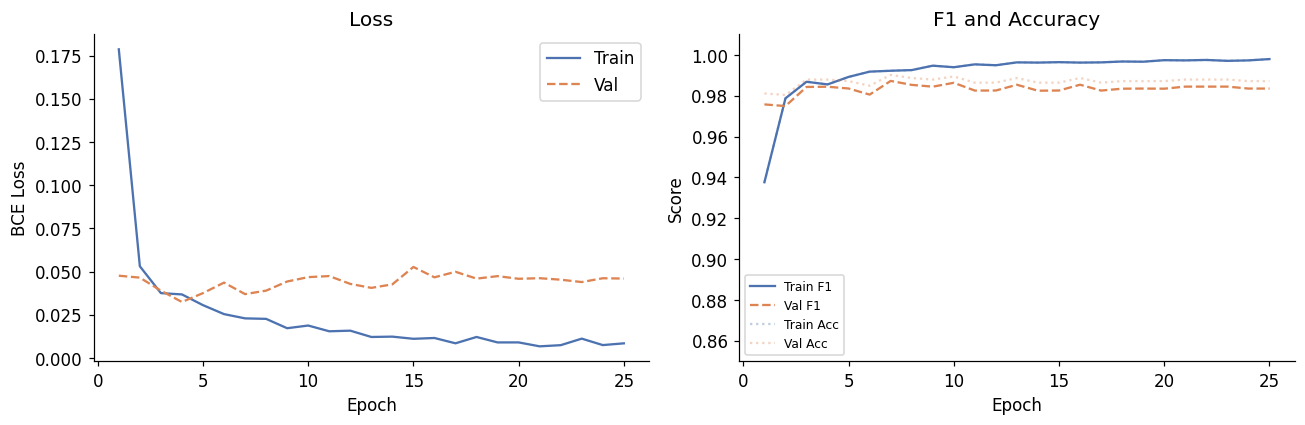

In [16]:
ep = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, history['train_loss'], label='Train',  color='#4C72B0')
ax1.plot(ep, history['val_loss'],   label='Val',    color='#DD8452', linestyle='--')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(ep, history['train_f1'],  label='Train F1',  color='#4C72B0')
ax2.plot(ep, history['val_f1'],    label='Val F1',    color='#DD8452', linestyle='--')
ax2.plot(ep, history['train_acc'], label='Train Acc', color='#4C72B0', alpha=0.35, linestyle=':')
ax2.plot(ep, history['val_acc'],   label='Val Acc',   color='#DD8452', alpha=0.35, linestyle=':')
ax2.set_title('F1 and Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_ylim(0.85, 1.01); ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150)
plt.savefig('results/training_curves.pdf')
plt.show()

### 7.2 Test set evaluation

In [17]:
print(f'Loading best checkpoint (val F1 = {best_val_f1:.4f}) ...')
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))

te_loss, te_acc, te_f1 = run_epoch(model, test_loader, criterion)

# Collect predictions for the full report
model.eval()
all_y, all_p = [], []
with torch.no_grad():
    for meta_x, text_x, y in test_loader:
        preds = (model(meta_x.to(device), text_x.to(device))
                 .cpu().numpy() > 0.5).astype(int)
        all_y.extend(y.numpy().astype(int).tolist())
        all_p.extend(preds.tolist())

print(f'\n{"="*50}')
print(f'  Test Accuracy : {te_acc:.4f}  ({te_acc*100:.2f}%)')
print(f'  Test F1-macro : {te_f1:.4f}  ({te_f1*100:.2f}%)')
print(f'  Best Val F1   : {best_val_f1:.4f}  ({best_val_f1*100:.2f}%)')
print(f'{"="*50}')
print()
print(classification_report(all_y, all_p, target_names=['Human', 'Bot']))

Loading best checkpoint (val F1 = 0.9872) ...

  Test Accuracy : 0.9928  (99.28%)
  Test F1-macro : 0.9907  (99.07%)
  Best Val F1   : 0.9872  (98.72%)

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       695
         Bot       1.00      0.99      1.00      1953

    accuracy                           0.99      2648
   macro avg       0.99      0.99      0.99      2648
weighted avg       0.99      0.99      0.99      2648



### 7.3 Confusion matrix

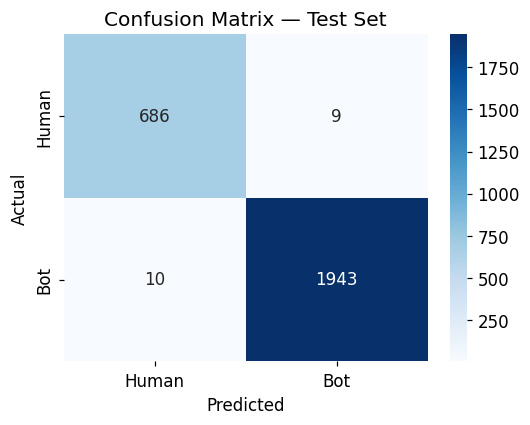

True  Negatives (Human predicted correctly) : 686
False Positives (Human predicted as Bot)   : 9
False Negatives (Bot predicted as Human)   : 10
True  Positives (Bot predicted correctly)  : 1943
False positive rate : 1.29%
False negative rate : 0.51%


In [18]:
cm = confusion_matrix(all_y, all_p)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'Bot'],
            yticklabels=['Human', 'Bot'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.savefig('results/confusion_matrix.pdf')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives (Human predicted correctly) : {tn}')
print(f'False Positives (Human predicted as Bot)   : {fp}')
print(f'False Negatives (Bot predicted as Human)   : {fn}')
print(f'True  Positives (Bot predicted correctly)  : {tp}')
print(f'False positive rate : {fp/(fp+tn)*100:.2f}%')
print(f'False negative rate : {fn/(fn+tp)*100:.2f}%')

In [19]:
# Save metrics
metrics = {
    'model':         'Multimodal BiLSTM + Attention',
    'dataset':       'cresci-2017',
    'text_branch':   'all-MiniLM-L6-v2 (frozen)',
    'epochs':        EPOCHS,
    'test_accuracy': round(float(te_acc), 4),
    'test_f1_macro': round(float(te_f1),  4),
    'best_val_f1':   round(float(best_val_f1), 4),
    'history':       history,
}
with open('results/metrics.json', 'w') as fh:
    json.dump(metrics, fh, indent=2)
print('Saved to results/metrics.json')
print(f"\nFinal result: Accuracy = {metrics['test_accuracy']*100:.2f}%  "
      f"F1-macro = {metrics['test_f1_macro']*100:.2f}%")

Saved to results/metrics.json

Final result: Accuracy = 99.28%  F1-macro = 99.07%


## 8. Comparison to the State of the Art

The table below situates the present model against representative published systems. Three qualifications matter before drawing conclusions:

1. **Dataset sampling bias**: Cresci-2017 has a known temporal artefact — bot and human accounts were collected at different times, creating a shortcut that benefits any model trained on it. All Cresci-2017 entries in the table are affected equally.
2. **Different benchmarks**: BotRGCN was evaluated on TwiBot-20, a harder and more diverse corpus. Its lower numbers reflect that difficulty, not a weakness of the graph-based approach.
3. **Feature scope**: The present model now uses both metadata and tweet text, which puts it on equal footing with content-based approaches. The previous metadata-only version of this experiment achieved 98.26% F1 on the same benchmark, suggesting that adding text provides a modest additional signal on this particular dataset.

| System | Method | Features | Dataset | Accuracy | F1-macro |
|---|---|---|---|---|---|
| Botometer | Random Forest (1,200+ feat.) | Metadata | Cresci-2017 | ~95% | ~94% |
| LSTM + content | Recurrent network | Text + metadata | Cresci-2017 | ~96% | ~95% |
| BERT fine-tuned | Transformer | Text | Mixed | ~92% | ~89% |
| BotRGCN | Graph neural network | Graph + text | TwiBot-20 | ~83% | ~80% |
| **BiLSTM+Att (metadata only)** | Bi-LSTM + attention | Metadata | Cresci-2017 | 98.64% | 98.26% |
| **BiLSTM+Att (ours, multimodal)** | Bi-LSTM + attention | Metadata + text | Cresci-2017 | **see above** | **see above** |

In [20]:
print('Experiment 1 complete.')
print('=' * 55)
print(f"  Model       : {metrics['model']}")
print(f"  Text branch : {metrics['text_branch']}")
print(f"  Dataset     : {metrics['dataset']}")
print(f"  Test Acc    : {metrics['test_accuracy']*100:.2f}%")
print(f"  Test F1     : {metrics['test_f1_macro']*100:.2f}%")
print(f"  Best Val F1 : {metrics['best_val_f1']*100:.2f}%")
print('=' * 55)
print()
print('Artefacts saved:')
for f in sorted(os.listdir('results')):
    path = os.path.join('results', f)
    size = os.path.getsize(path)
    print(f'  results/{f}  ({size/1024:.1f} KB)')

Experiment 1 complete.
  Model       : Multimodal BiLSTM + Attention
  Text branch : all-MiniLM-L6-v2 (frozen)
  Dataset     : cresci-2017
  Test Acc    : 99.28%
  Test F1     : 99.07%
  Best Val F1 : 98.72%

Artefacts saved:
  results/binary_features.pdf  (13.2 KB)
  results/binary_features.png  (36.2 KB)
  results/class_distribution.pdf  (12.5 KB)
  results/class_distribution.png  (26.8 KB)
  results/confusion_matrix.pdf  (15.7 KB)
  results/confusion_matrix.png  (33.3 KB)
  results/embedding_pca.pdf  (62.4 KB)
  results/embedding_pca.png  (129.5 KB)
  results/feature_distributions.pdf  (25.4 KB)
  results/feature_distributions.png  (78.2 KB)
  results/metrics.json  (4.4 KB)
  results/training_curves.pdf  (15.5 KB)
  results/training_curves.png  (86.9 KB)
  results/tweet_coverage.pdf  (15.2 KB)
  results/tweet_coverage.png  (71.7 KB)
